In [67]:
import pandas as pd
import yfinance as yf
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

In [68]:
tickers = ['NKE', 'SPOT', 'T', 'JPM', 'DIS', 'TM', 'KO']

data = yf.download(tickers=tickers,auto_adjust=False, period= '2y', interval = '1d')

data = data['Adj Close']

[*********************100%***********************]  7 of 7 completed


In [ ]:
log_returns = np.log(data/data.shift(1))

In [ ]:
portfolio_returns = []
portfolio_volatilities = []
for x in range(1000):
    weights = np.random.random(len(tickers))
    weights /= np.sum(weights)
    
    portfolio_returns.append(np.sum(weights * log_returns.mean()) * 250)
    portfolio_volatilities.append(np.sqrt(np.dot(weights.T, np.dot(log_returns.cov() * 250, weights))))
                    
portfolio_returns = np.array(portfolio_returns)                                                     ### instructions and code retrieved from
portfolio_volatilities = np.array(portfolio_volatilities)                                           ### https://medium.com/@zeng.simonl/the-efficient-frontier-in-python-a1bc9496a0a1
                                  

In [72]:
portfolios = pd.DataFrame({
    'Volatility': portfolio_volatilities,
    'Return': portfolio_returns
})

portfolios = portfolios.sort_values(by='Volatility')


In [73]:
efficient_frontier = portfolios[portfolios['Return'] == portfolios['Return'].cummax()]
coeffs = np.polyfit(efficient_frontier['Volatility'], efficient_frontier['Return'], deg=2)
poly = np.poly1d(coeffs)
vol_range = np.linspace(efficient_frontier['Volatility'].min(), efficient_frontier['Volatility'].max(), 500)
ret_smooth = poly(vol_range)


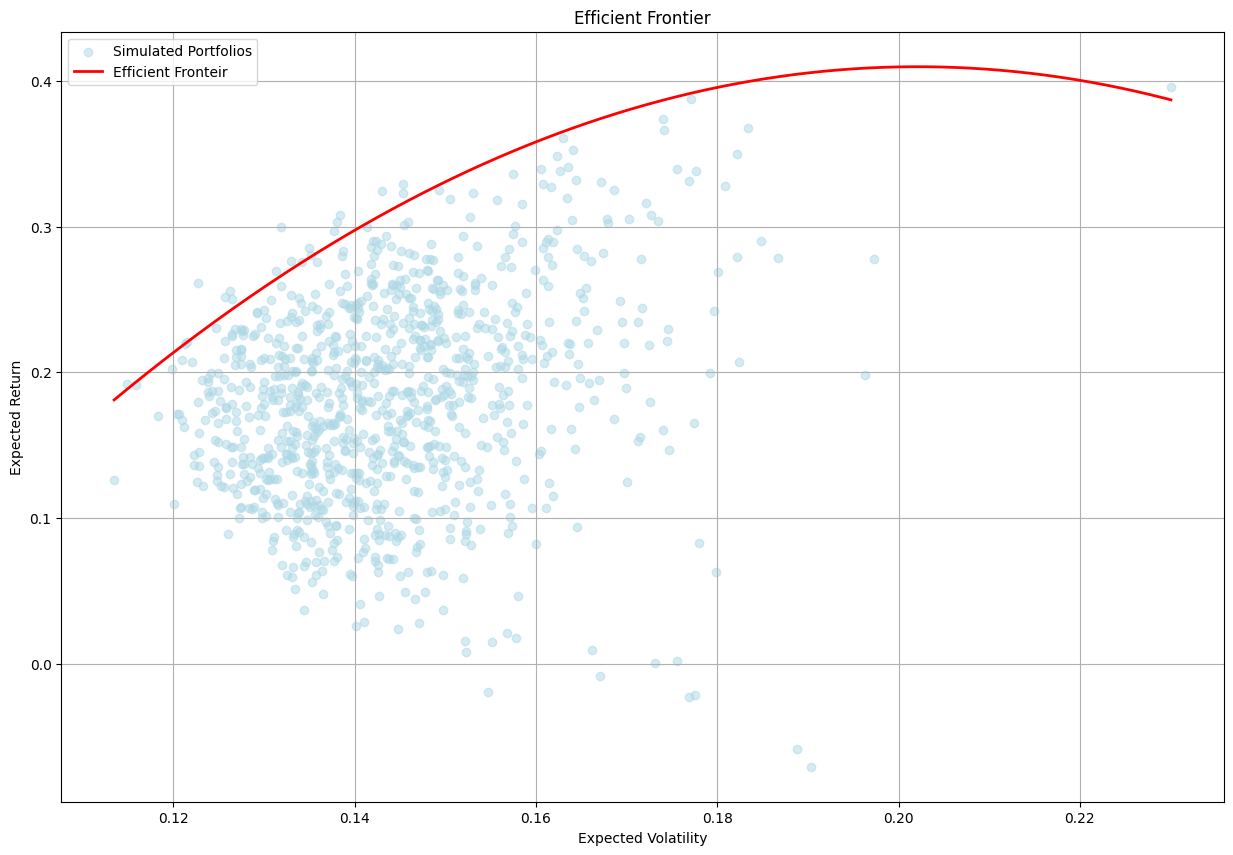

In [74]:
plt.figure(figsize=(15, 10))
plt.scatter(portfolios['Volatility'], portfolios['Return'], c='lightblue', alpha=0.5, label='Simulated Portfolios')
plt.plot(vol_range, ret_smooth, 'red', linewidth=2, label='Efficient Fronteir')
plt.xlabel('Expected Volatility')
plt.ylabel('Expected Return')
plt.title('Efficient Frontier')
plt.legend()
plt.grid(True)
plt.show()


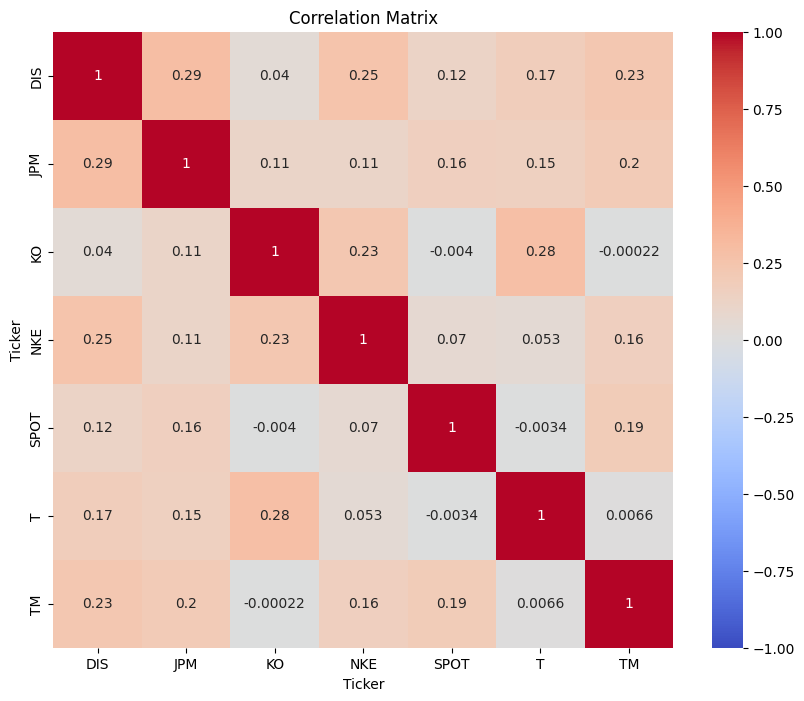

In [75]:
correlation_matrix = log_returns.corr()
plt.figure(figsize=(10, 8))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', vmin=-1, vmax=1)
plt.title('Correlation Matrix')
plt.show()